In [12]:
#%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.integrate as integrate

%load_ext autoreload
%autoreload 2

from GP_code import simulate_population_single, get_mean_trajectory_single, simulate_population_double, get_mean_trajectory_double



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [83]:
def example_rates_single(t):
    # Example: rates depend on drug concentration
    l = 0.05 * np.sin(0.1 * t) + 0.1 # Birth rate
    mu = 0.08 # Death rate increases over time
    return l, mu

In [3]:
#True value: E[Z(t)]
import scipy.integrate as integrate

def func(t):
    return (0.05 * np.sin(0.1 * t) + 0.1) - 0.08

def func_sens(t):
    return np.exp(0.05/0.1 + (0.1-0.08)*t - (0.05/0.1)*np.cos(0.1*t)) * (0.05*np.sin(0.1 * t) + 0.1)


def calc_expectation(Z0, func, t):
    value, error = Z0 * np.exp(integrate.quad(func, 0, t))
    return value

def calc_cell_division(func_sens, t):
    '''
    Top right of page 183
    '''
    
    value, error = integrate.quad(func_sens, 0, t)
    return value



In [4]:
vals = np.linspace(0, 250, 250)
store = np.zeros(len(vals))
for i, _ in enumerate(vals):
    store[i] = calc_expectation(1, func, _)
    

Fig 1(a): E[Y(t)]: Expected number of sensitive cells for a single-type non-homogenous birth-death process

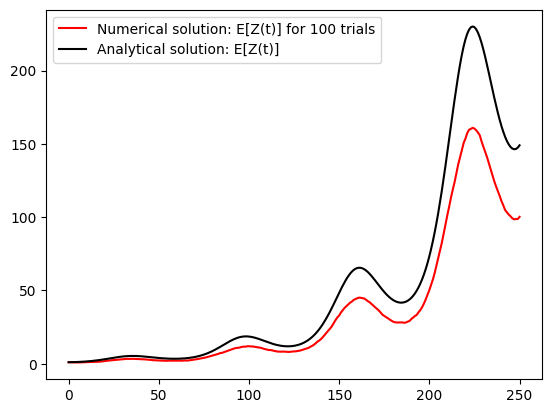

In [84]:
N = 100 #Number of trials
grid, mean_pop, mean_divs = get_mean_trajectory_single(N, 250, 1, example_rates_single, 0.3)
plt.plot(grid, mean_pop, c = 'red', label = f'Numerical solution: E[Z(t)] for {N} trials' )
plt.plot(vals, store, c = 'black', linestyle = '-', label = 'Analytical solution: E[Z(t)]')
plt.legend()

plt.show()

Fig 1 (b): birth-death rate over time

<Axes: >

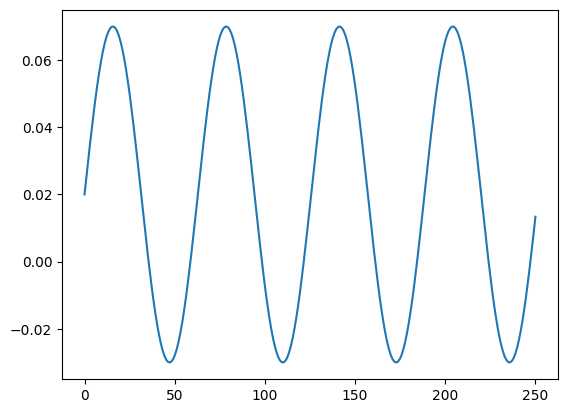

In [9]:
time = np.linspace(0, 250, 250)
y_axis = np.zeros(len(time))
for i, n in enumerate(time):
    y_axis[i] = func(n)

sns.lineplot(x = time, y = y_axis)

In [15]:
vals_c = np.linspace(0, 250, 250)
store_c = np.zeros(len(vals_c))
for i, _ in enumerate(vals_c):
    store_c[i] = calc_cell_division(func_sens, _)

Fig 1(c): Number of sensitive cell divisions

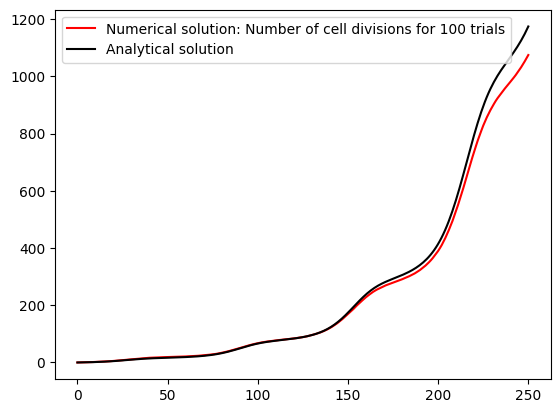

In [16]:
plt.plot(grid, mean_divs, c = 'red', label = f'Numerical solution: Number of cell divisions for {N} trials' )
plt.plot(vals_c, store_c, c = 'black', linestyle = '-', label = 'Analytical solution')
plt.legend()

plt.show()

Fig 1(extra): Variance

In [ ]:
# def w_tau(tau):
#     value, error
#     return 0

Fig 2(a): Expected number of resistant cells

In [91]:
def example_rates_double(t, C2):
    # Example: rates depend on drug concentration
    l_x = 0.05 * np.sin(0.1 * t) + 0.1 # Birth rate sensitive cells
    l_y = 0.05 * np.sin(0.1 * t) + 0.12 # Birth rate resistant cells
    mu_x = 0.14 # death rate of sensitive cells
    mu_y = C2 # death rate of resistant cells
    return l_x, l_y, mu_x, mu_y

In [92]:
#Define analytical result of expected size of resistant cell population
#l_x = 0.05sin(0.1t)+0.1
#mu_x = 0.14
#l_y = 0.05sin(0.1t)+0.12
#mu_y = [0.09, 0.1, 0.11]
#M = 100
#u = 10**-3
def b_tau(tau):
    term1 = (0.05/0.1) + ((0.1 - 0.14)*tau) - ((0.05/0.1)*np.cos(0.1*tau))
    term2 = (0.05*np.sin(0.1*tau) + 0.1)*1e-3
    return 100 * np.exp(term1)*term2

def R_t(t, C2):
    def integral(tau):
        #b_tau(t)
        term1 = (0.05/0.1)*np.cos(0.1*tau) - (0.05/0.1)*np.cos(0.1*t) + (0.12-C2)*t +(C2-0.12)*tau
        func = b_tau(tau)*np.exp(term1)
        return func
    value, error = integrate.quad(integral, 0, t)
    return value

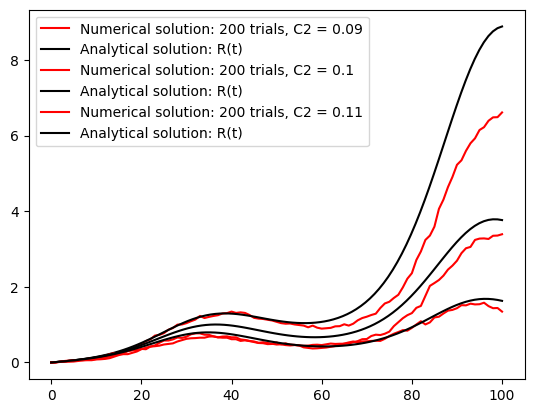

In [98]:
N = 200 #Number of trials
T_max = 100
M0 = 100
R0 = 0
beta = 0.7
u = 1e-3
#C2 = 0.09
for C2 in [0.09, 0.1, 0.11]:
    grid, mean_pop, mean_r = get_mean_trajectory_double(N, T_max, M0, R0, example_rates_double, beta, u, C2)
    plt.plot(grid, mean_r, c = 'red', label = f'Numerical solution: {N} trials, C2 = {C2}' )

    vals_r = np.linspace(0, 100, 100)
    store_r = np.zeros(len(vals_r))
    for i, _ in enumerate(vals_r):
        store_r[i] = R_t(_, C2)
    plt.plot(vals_r, store_r, c = 'black', linestyle = '-', label = 'Analytical solution: R(t)')
    plt.legend()

plt.show()

Fig 2(b): Probability of Resistance

In [99]:
#b_tau already defined
#We are looking for P_r(T) = 1- exp(integral(-b + b * P_ext dt)from 0 T)
#define p_ext as Q/1+Q
def b_t(tau):
    term1 = (0.05/0.1) + ((0.1 - 0.14)*tau) - ((0.05/0.1)*np.cos(0.1*tau))
    term2 = (0.05*np.sin(0.1*tau) + 0.1)*1e-3
    return 100 * np.exp(term1)*term2

def P_rt (t, T, B1):
    def P_exp():
        def integral(t, T):
            def Q(tau):
                #b_tau(t)
                term1 = (0.05/0.1)*np.cos(0.1*(tau+t)) - (0.05/0.1)*np.cos(0.1*t) - (0.1)*tau
                func = 0.1*np.exp(term1)
                return func
            value, error = integrate.quad(Q, 0, T-t)
            return value
        p_exp = integral/(1+integral)
        return p_exp
    term = -b_t(t) + (b_t(t) * P_exp)
    value, error = integrate.quad(term, 0, T)
    return 1 - np.exp(value)

In [ ]:
M = 100
u = 1e-3
theta = 0.1
A = 0.05
C1 = 0.14
B2, C2 = 0.12, 0.1 

def get_b_t(t, B1):
    # This is b(t): the rate of production of resistant cells at time t
    # Integral of (l_x - mu_x) = (A/y) - (A/y)cos(yt) + (B1-C1)t
    exponent = (A/theta) - (A/theta)*np.cos(theta*t) + (B1 - C1)*t
    S_t = M * np.exp(exponent)
    l_x_t = A * np.sin(theta*t) + B1
    return S_t * l_x_t * u

def get_Q(t, T):
    # Q is the integral from 0 to (T-t)
    def Q_integrand(tau):
        # Integral of (l_y - mu_y) from t to t+tau
        # = [-(A/y)cos(y*zeta) + (B2-C2)zeta] evaluated from t to t+tau
        # term_future = -(A/theta)*np.cos(theta*(t + tau)) + (B2 - C2)*tau
        # term_birth = -(A/theta)*np.cos(theta*t)
        # # Note: (B2-C2)*t is NOT in the exponent for the 'relative' growth 
        # # because we are integrating from t to t+tau
        # growth_exponent = term_future - term_birth + (B2 - C2)*t
        
        # Actually, based on your paper's Q formula:
        # A2/y*cos(y(t+tau)) - A2/y*cos(yt) + (B2-C2)tau
        # Let's follow your specific Q formula precisely:
        q_exp = (A/theta)*np.cos(theta*(t+tau)) - (A/theta)*np.cos(theta*t) - (B2 - C2)*tau
        return C2 * np.exp(q_exp)

    val, _ = integrate.quad(Q_integrand, 0, T - t)
    return val

def get_P_ext(t, T):
    Q_val = get_Q(t, T)
    return Q_val / (1 + Q_val)

def P_R(T, B1):
    # Final integral from 0 to T of [-b(t) + b(t)*P_ext(t,T)]
    def final_integrand(t):
        bt = get_b_t(t, B1)
        pext = get_P_ext(t, T)
        return -bt + (bt * pext)

    integral_val, _ = integrate.quad(final_integrand, 0, T)
    return 1 - np.exp(integral_val)

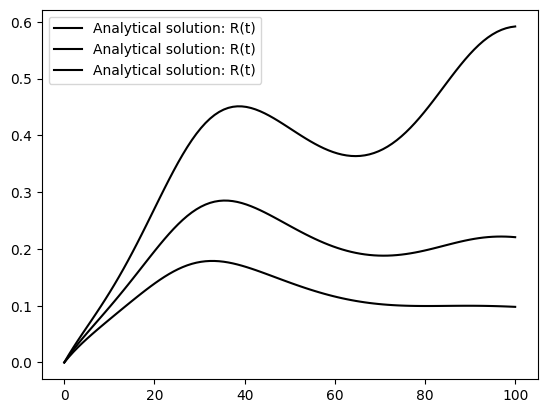

In [111]:
for B1 in [0.1, 0.12, 0.14]:
    vals_r = np.linspace(0, 100, 100)
    store_r = np.zeros(len(vals_r))
    for i, _ in enumerate(vals_r):
        store_r[i] = P_R(_, B1)
    plt.plot(vals_r, store_r, c = 'black', linestyle = '-', label = 'Analytical solution: R(t)')
    plt.legend()
plt.show()